# CRISP-DM ML Pipeline: Predicting Fraud in Shop Orders
**Course: BIS 455 | Part 2: Fraud Detection Pipeline**

This notebook follows the full CRISP-DM process to build a fraud detection model using the `shop.db` operational database. It includes both a Multiple Linear Regression (MLR) component predicting `risk_score` and a categorical classification component predicting `is_fraud`.

---
## Section 1 — Business Understanding

### Problem Definition

Online retail fraud costs merchants billions of dollars annually. The goal of this project is to build an automated ML pipeline that flags fraudulent orders before they are fulfilled, allowing the warehouse team to review high-risk transactions.

**Primary target**: `is_fraud` — a binary label on each order (1 = fraud, 0 = legitimate)  
**Secondary target**: `risk_score` — a continuous 0–100 risk rating used for the MLR component

### Success Criteria

| Metric | Threshold | Reasoning |
|--------|-----------|----------|
| ROC-AUC | ≥ 0.90 | Measures overall ranking ability across all thresholds |
| Recall (fraud class) | ≥ 0.80 | Missing a fraud order (false negative) is costlier than a false alarm |
| Precision (fraud class) | ≥ 0.50 | Avoid overwhelming the review team with false positives |

### Fraud Detection as a Cost-Sensitive Problem

- **False Negative** (missed fraud): Direct financial loss, chargebacks, reputational damage — **high cost**
- **False Positive** (flagged legitimate order): Manual review cost, customer friction — **low cost**

This asymmetry means we should optimize for **Recall** on the fraud class and use `class_weight='balanced'` during training to prevent the model from ignoring the minority class (~6.4% of orders).

---
## Section 2 — Data Understanding

In [1]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DB_PATH = 'data/shop.db'
conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)

Connected to data/shop.db


In [2]:
# Load orders joined with customers
query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_datetime,
    o.billing_zip,
    o.shipping_zip,
    o.shipping_state,
    o.payment_method,
    o.device_type,
    o.ip_country,
    o.promo_used,
    o.promo_code,
    o.order_subtotal,
    o.shipping_fee,
    o.tax_amount,
    o.order_total,
    o.risk_score,
    o.is_fraud,
    c.gender,
    c.birthdate,
    c.created_at,
    c.customer_segment,
    c.loyalty_tier
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
"""
df_raw = pd.read_sql(query, conn)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (5000, 22)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,gender,birthdate,created_at,customer_segment,loyalty_tier
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.9500,15.4400,46.3000,724.6900,38.3000,0,Female,2005-06-08,2025-10-11 16:37:40,standard,silver
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.9200,14.7400,66.6100,944.2700,94.9000,0,Female,2005-06-08,2025-10-11 16:37:40,standard,silver
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.0900,14.0400,40.7200,850.8500,53.8000,1,Female,2005-06-08,2025-10-11 16:37:40,standard,silver
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,WELCOME,137.6000,6.9900,11.8800,156.4700,4.2000,0,Female,2005-06-08,2025-10-11 16:37:40,standard,silver
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,None,17.0700,6.9900,1.4000,25.4600,4.9000,0,Female,2005-06-08,2025-10-11 16:37:40,standard,silver


In [3]:
# Basic info and missing values
print('--- Data Types ---')
print(df_raw.dtypes)
print()
print('--- Missing Values ---')
print(df_raw.isna().sum())

--- Data Types ---
order_id              int64
customer_id           int64
order_datetime       object
billing_zip          object
shipping_zip         object
shipping_state       object
payment_method       object
device_type          object
ip_country           object
promo_used            int64
promo_code           object
order_subtotal      float64
shipping_fee        float64
tax_amount          float64
order_total         float64
risk_score          float64
is_fraud              int64
gender               object
birthdate            object
created_at           object
customer_segment     object
loyalty_tier         object
dtype: object

--- Missing Values ---
order_id               0
customer_id            0
order_datetime         0
billing_zip            0
shipping_zip           0
shipping_state         0
payment_method         0
device_type            0
ip_country             0
promo_used             0
promo_code          3739
order_subtotal         0
shipping_fee           0
ta

In [4]:
# Numeric summary
print('--- Numeric Summary ---')
df_raw.describe()

--- Numeric Summary ---


,order_id,customer_id,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,2500.5000,28.4482,0.2522,384.1447,9.6683,27.7383,421.5513,26.1159,0.0636
std,1443.5200,49.0869,0.4343,284.1240,5.1261,21.4465,305.1837,27.4338,0.2441
min,1.0000,1.0000,0.0000,4.7300,0.0000,0.2500,5.3800,0.1000,0.0000
25%,1250.7500,2.0000,0.0000,164.1800,6.9900,11.4700,185.7600,4.6000,0.0000
50%,2500.5000,6.0000,0.0000,330.7200,8.0400,23.3650,364.8350,14.5000,0.0000
75%,3750.2500,28.0000,1.0000,549.7525,12.9900,39.1525,596.9400,40.2250,0.0000
max,5000.0000,250.0000,1.0000,1921.1700,28.1400,148.1300,2053.1100,100.0000,1.0000


--- is_fraud Distribution ---
is_fraud
0    4682
1     318
Name: count, dtype: int64

Fraud rate: 6.36%
Note: Class imbalance — minority class is ~6.4% of orders


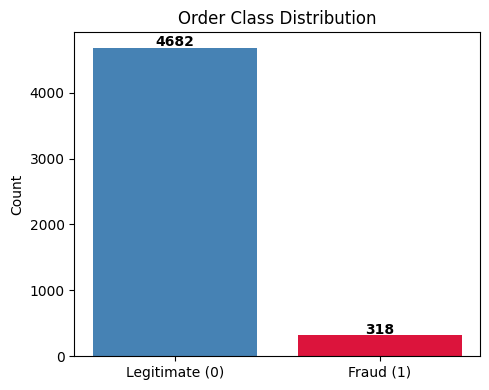

In [5]:
# Class distribution — is_fraud
fraud_counts = df_raw['is_fraud'].value_counts()
fraud_rate = df_raw['is_fraud'].mean() * 100

print('--- is_fraud Distribution ---')
print(fraud_counts)
print(f'\nFraud rate: {fraud_rate:.2f}%')
print('Note: Class imbalance — minority class is ~6.4% of orders')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Order Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

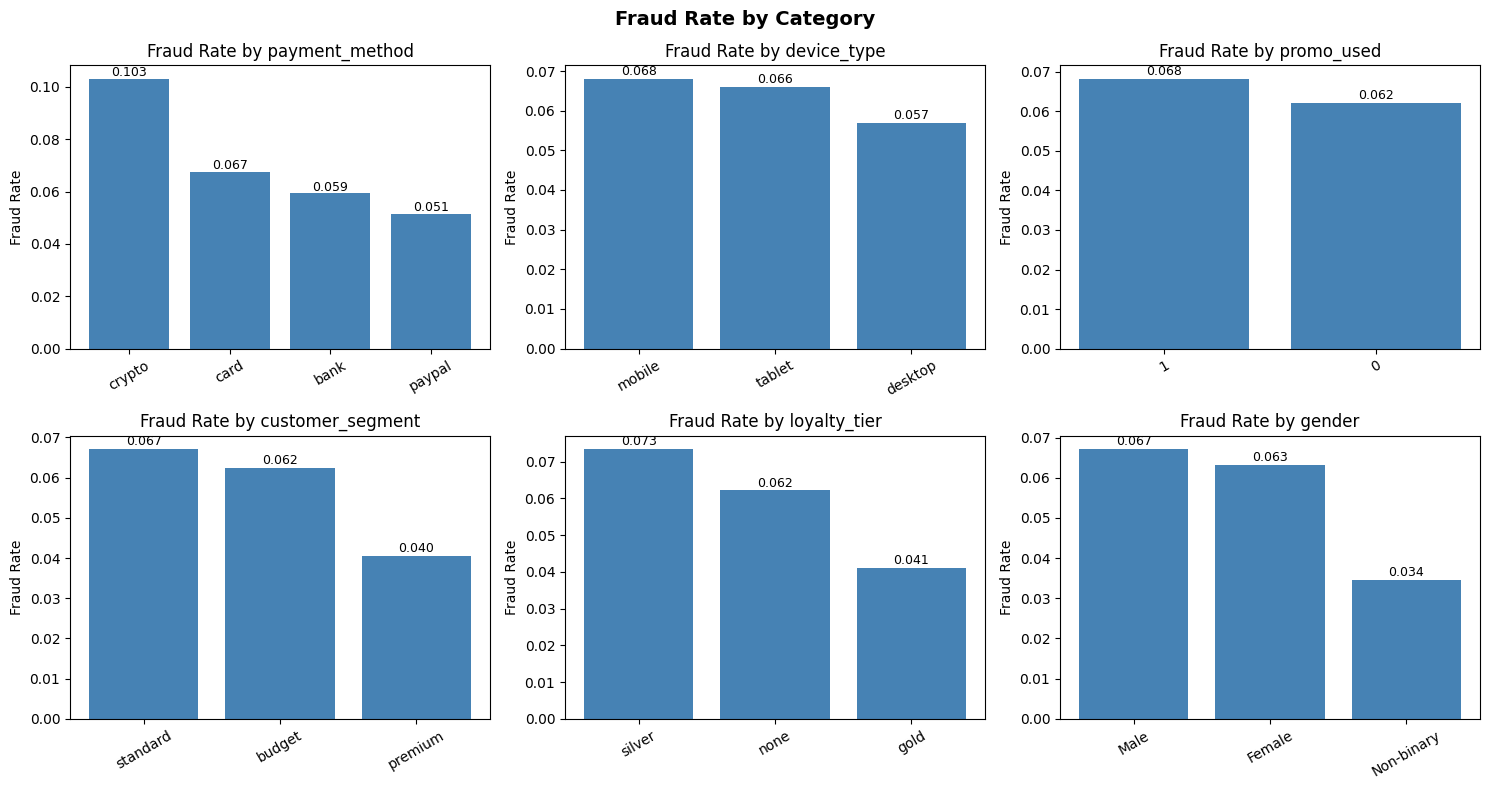

In [6]:
# Fraud rate by categorical features
cat_cols = ['payment_method', 'device_type', 'promo_used', 'customer_segment', 'loyalty_tier', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_by_col = df_raw.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    axes[i].bar(fraud_by_col.index.astype(str), fraud_by_col.values, color='steelblue')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(fraud_by_col.values):
        axes[i].text(j, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Fraud Rate by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

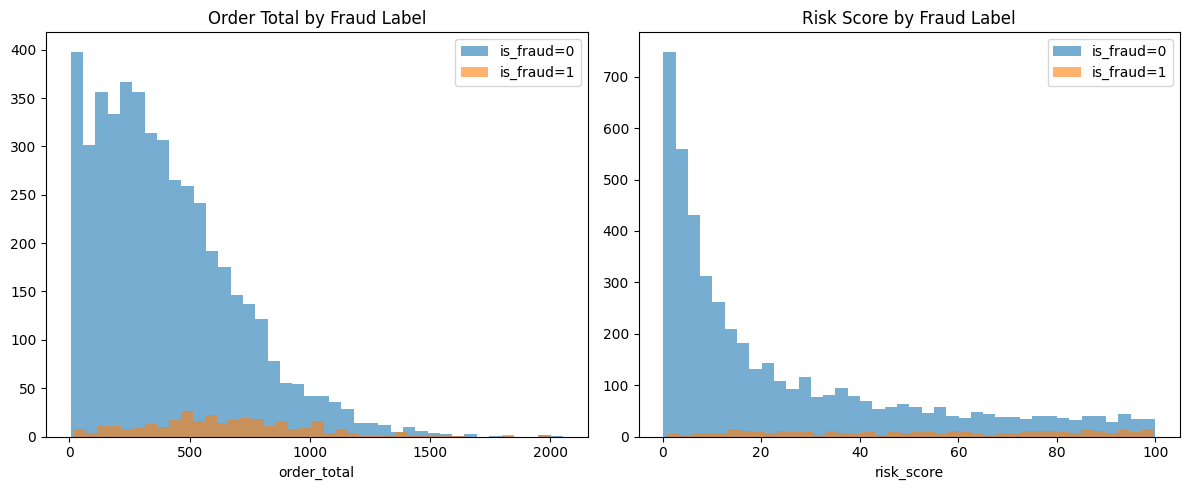

--- Mean values by fraud label ---
          order_total  risk_score
is_fraud                         
0            405.1520     24.1851
1            663.0031     54.5443


In [7]:
# Distribution of order_total and risk_score by fraud label
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, grp in df_raw.groupby('is_fraud'):
    axes[0].hist(grp['order_total'], bins=40, alpha=0.6, label=f'is_fraud={label}')
    axes[1].hist(grp['risk_score'], bins=40, alpha=0.6, label=f'is_fraud={label}')

axes[0].set_title('Order Total by Fraud Label')
axes[0].set_xlabel('order_total')
axes[0].legend()

axes[1].set_title('Risk Score by Fraud Label')
axes[1].set_xlabel('risk_score')
axes[1].legend()

plt.tight_layout()
plt.show()

print('--- Mean values by fraud label ---')
print(df_raw.groupby('is_fraud')[['order_total', 'risk_score']].mean())

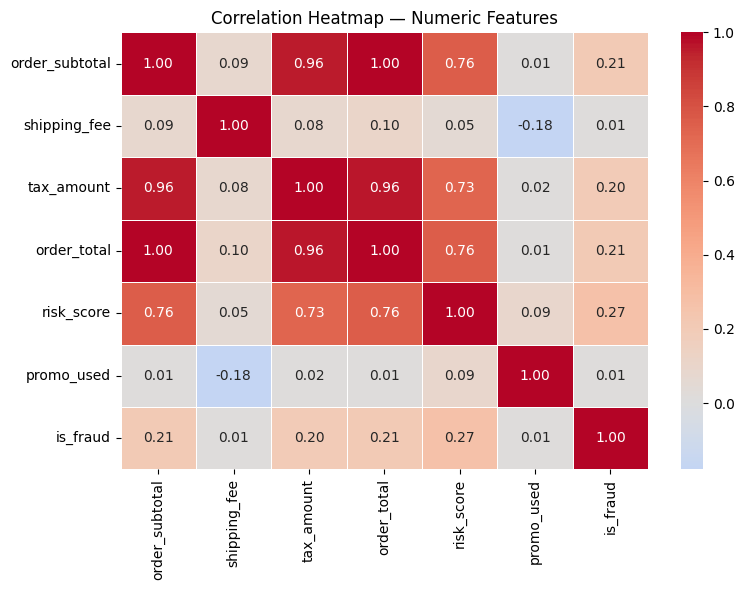

In [8]:
# Correlation heatmap — numeric features
numeric_cols = ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'promo_used', 'is_fraud']
corr = df_raw[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

---
## Section 3 — Data Preparation

In [9]:
# Work on a copy
df = df_raw.copy()

# Parse datetime columns
df['order_datetime'] = pd.to_datetime(df['order_datetime'])
df['created_at'] = pd.to_datetime(df['created_at'])
df['birthdate'] = pd.to_datetime(df['birthdate'])

print('Datetime columns parsed successfully.')

Datetime columns parsed successfully.


In [10]:
# Feature Engineering

# Zip mismatch — billing zip differs from shipping zip (fraud signal)
df['zip_mismatch'] = (df['billing_zip'] != df['shipping_zip']).astype(int)

# Time-based features
df['order_hour'] = df['order_datetime'].dt.hour
df['order_dayofweek'] = df['order_datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df['is_weekend'] = (df['order_dayofweek'] >= 5).astype(int)
df['is_night'] = ((df['order_hour'] >= 22) | (df['order_hour'] < 6)).astype(int)

# Customer age at time of order
df['customer_age'] = ((df['order_datetime'] - df['birthdate']).dt.days / 365.25).round(1)

# Days since customer signed up
df['days_since_signup'] = (df['order_datetime'] - df['created_at']).dt.days

engineered = ['zip_mismatch', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_night', 'customer_age', 'days_since_signup']
print('Engineered features:')
print(df[engineered].describe())

Engineered features:
       zip_mismatch  order_hour  order_dayofweek  is_weekend  is_night  \
count     5000.0000   5000.0000        5000.0000   5000.0000 5000.0000   
mean         0.0784     11.5442           3.0268      0.2860    0.3334   
std          0.2688      6.9554           2.0041      0.4519    0.4715   
min          0.0000      0.0000           0.0000      0.0000    0.0000   
25%          0.0000      5.0000           1.0000      0.0000    0.0000   
50%          0.0000     12.0000           3.0000      0.0000    0.0000   
75%          0.0000     18.0000           5.0000      1.0000    1.0000   
max          1.0000     23.0000           6.0000      1.0000    1.0000   

       customer_age  days_since_signup  
count     5000.0000          5000.0000  
mean        31.5526            77.0674  
std         14.4175           106.6131  
min         18.4000          -123.0000  
25%         20.4000            -5.0000  
50%         24.9500            60.0000  
75%         36.0000      

In [11]:
# Verify no nulls in engineered features
print('Null counts in engineered features:')
print(df[engineered].isna().sum())

Null counts in engineered features:
zip_mismatch         0
order_hour           0
order_dayofweek      0
is_weekend           0
is_night             0
customer_age         0
days_since_signup    0
dtype: int64


In [12]:
# Define feature sets
# Exclude: order_id, customer_id, promo_code (high cardinality text), raw dates, targets

NUMERIC_FEATURES = [
    'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total',
    'zip_mismatch', 'order_hour', 'order_dayofweek', 'is_weekend',
    'is_night', 'customer_age', 'days_since_signup'
]

CATEGORICAL_FEATURES = [
    'payment_method', 'device_type', 'shipping_state',
    'gender', 'customer_segment', 'loyalty_tier'
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

TARGET_CLASS = 'is_fraud'
TARGET_REGR  = 'risk_score'

X = df[ALL_FEATURES].copy()
y_class = df[TARGET_CLASS].copy()
y_regr  = df[TARGET_REGR].copy()

print('Feature matrix shape:', X.shape)
print('Numeric features:', len(NUMERIC_FEATURES))
print('Categorical features:', len(CATEGORICAL_FEATURES))

Feature matrix shape: (5000, 17)
Numeric features: 11
Categorical features: 6


In [13]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve ~6.4% fraud rate in both sets
X_train, X_test, y_class_train, y_class_test, y_regr_train, y_regr_test = train_test_split(
    X, y_class, y_regr,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print(f'Train fraud rate: {y_class_train.mean():.4f}')
print(f'Test  fraud rate: {y_class_test.mean():.4f}')

Train size: 4000
Test size: 1000
Train fraud rate: 0.0635
Test  fraud rate: 0.0640


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Automated data preparation pipeline (Ch. 7)
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_FEATURES),
    ('cat', categorical_pipe, CATEGORICAL_FEATURES)
])

print('Preprocessing pipeline defined.')
print('Numeric steps:', [s[0] for s in numeric_pipe.steps])
print('Categorical steps:', [s[0] for s in categorical_pipe.steps])

Preprocessing pipeline defined.
Numeric steps: ['imputer', 'scaler']
Categorical steps: ['imputer', 'encoder']


---
## Section 4 — Modeling

### Section 4a — MLR: Predicting `risk_score` (Continuous Target)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Build MLR pipeline
mlr_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('mlr', LinearRegression())
])

mlr_pipe.fit(X_train, y_regr_train)

y_pred_regr = mlr_pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_regr_test, y_pred_regr))
r2   = r2_score(y_regr_test, y_pred_regr)

print(f'MLR — RMSE: {rmse:.4f}')
print(f'MLR — R²:   {r2:.4f}')

MLR — RMSE: 11.9349
MLR — R²:   0.8126


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


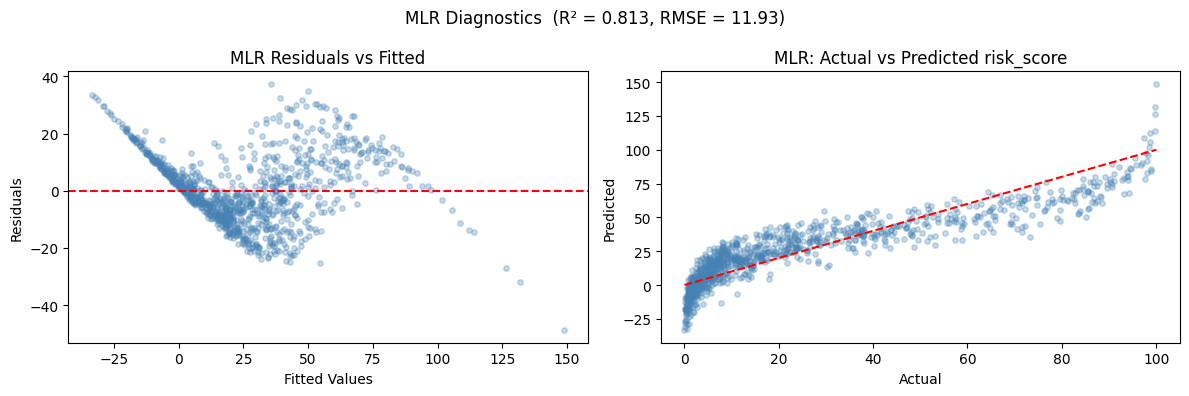

In [16]:
# Residual plot
residuals = y_regr_test - y_pred_regr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_regr, residuals, alpha=0.3, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('MLR Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

axes[1].scatter(y_regr_test, y_pred_regr, alpha=0.3, s=15, color='steelblue')
axes[1].plot([y_regr_test.min(), y_regr_test.max()],
             [y_regr_test.min(), y_regr_test.max()], 'r--')
axes[1].set_title('MLR: Actual vs Predicted risk_score')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.suptitle(f'MLR Diagnostics  (R² = {r2:.3f}, RMSE = {rmse:.2f})', fontsize=12)
plt.tight_layout()
plt.show()

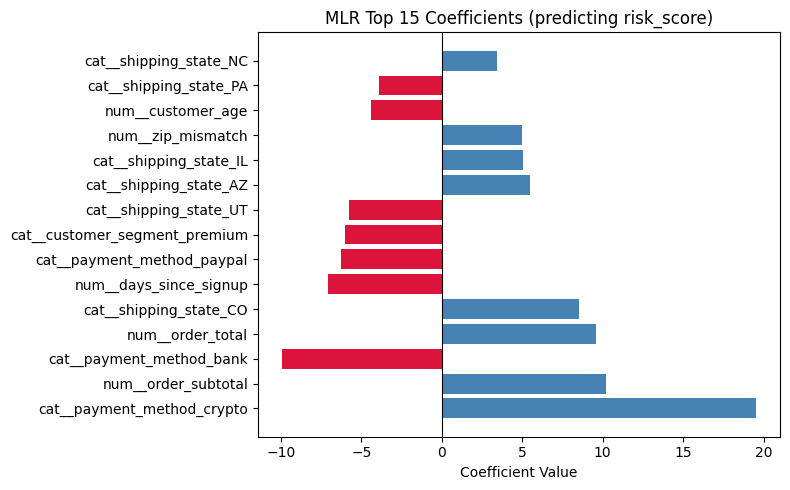

In [17]:
# MLR Coefficients — top 15 by absolute magnitude
mlr_model = mlr_pipe.named_steps['mlr']
feature_names_out = mlr_pipe.named_steps['preprocess'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names_out,
    'coefficient': mlr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(8, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('MLR Top 15 Coefficients (predicting risk_score)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

### Section 4b — Classification: Predicting `is_fraud` (Binary Target)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':          'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc':           'roc_auc',
    'f1':                'f1',
    'precision':         'precision',
    'recall':            'recall'
}

# --- Baseline: Logistic Regression ---
lr_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

lr_cv = cross_validate(lr_pipe, X_train, y_class_train, cv=skf, scoring=scoring)

print('=== Logistic Regression (5-Fold CV) ===')
for metric in scoring:
    vals = lr_cv[f'test_{metric}']
    print(f'  {metric:<20} mean={vals.mean():.4f}  std={vals.std():.4f}')

/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

=== Logistic Regression (5-Fold CV) ===
  accuracy             mean=0.7150  std=0.0212
  balanced_accuracy    mean=0.6881  std=0.0351
  roc_auc              mean=0.7569  std=0.0314
  f1                   mean=0.2270  std=0.0240
  precision            mean=0.1373  std=0.0152
  recall               mean=0.6573  std=0.0682


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmu

In [19]:
# --- Ensemble: Random Forest ---
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_cv = cross_validate(rf_pipe, X_train, y_class_train, cv=skf, scoring=scoring)

print('=== Random Forest (5-Fold CV) ===')
for metric in scoring:
    vals = rf_cv[f'test_{metric}']
    print(f'  {metric:<20} mean={vals.mean():.4f}  std={vals.std():.4f}')

/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


=== Random Forest (5-Fold CV) ===
  accuracy             mean=0.9363  std=0.0008
  balanced_accuracy    mean=0.4999  std=0.0003
  roc_auc              mean=0.7198  std=0.0277
  f1                   mean=0.0000  std=0.0000
  precision            mean=0.0000  std=0.0000
  recall               mean=0.0000  std=0.0000


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [20]:
# --- Ensemble: Gradient Boosting ---
gb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))
])

gb_cv = cross_validate(gb_pipe, X_train, y_class_train, cv=skf, scoring=scoring)

print('=== Gradient Boosting (5-Fold CV) ===')
for metric in scoring:
    vals = gb_cv[f'test_{metric}']
    print(f'  {metric:<20} mean={vals.mean():.4f}  std={vals.std():.4f}')

=== Gradient Boosting (5-Fold CV) ===
  accuracy             mean=0.9323  std=0.0009
  balanced_accuracy    mean=0.5124  std=0.0073
  roc_auc              mean=0.7118  std=0.0257
  f1                   mean=0.0550  std=0.0257
  precision            mean=0.2333  std=0.0624
  recall               mean=0.0315  std=0.0156


In [21]:
# Cross-validation comparison table
results = {}
for name, cv in [('Logistic Regression', lr_cv), ('Random Forest', rf_cv), ('Gradient Boosting', gb_cv)]:
    results[name] = {m: cv[f'test_{m}'].mean() for m in scoring}

results_df = pd.DataFrame(results).T
print('=== Cross-Validation Summary ===')
results_df

=== Cross-Validation Summary ===


,accuracy,balanced_accuracy,roc_auc,f1,precision,recall
Logistic Regression,0.7150,0.6881,0.7569,0.2270,0.1373,0.6573
Random Forest,0.9363,0.4999,0.7198,0.0000,0.0000,0.0000
Gradient Boosting,0.9323,0.5124,0.7118,0.0550,0.2333,0.0315


---
## Section 5 — Evaluation, Selection, and Tuning

In [22]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest — grid search over key hyperparameters
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth':    [None, 10, 20],
    'clf__min_samples_leaf': [1, 5]
}

grid_rf = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_class_train)

print('Best params:', grid_rf.best_params_)
print(f'Best CV ROC-AUC: {grid_rf.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.7512


In [23]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Evaluate all three models on held-out test set
models = {
    'Logistic Regression': lr_pipe,
    'Random Forest (tuned)': grid_rf.best_estimator_,
    'Gradient Boosting': gb_pipe
}

# Fit models that haven't been fit on full training data yet
for name, model in models.items():
    if name != 'Random Forest (tuned)':  # already fit inside GridSearchCV
        model.fit(X_train, y_class_train)

print('All models trained on full training set.')

/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

All models trained on full training set.


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


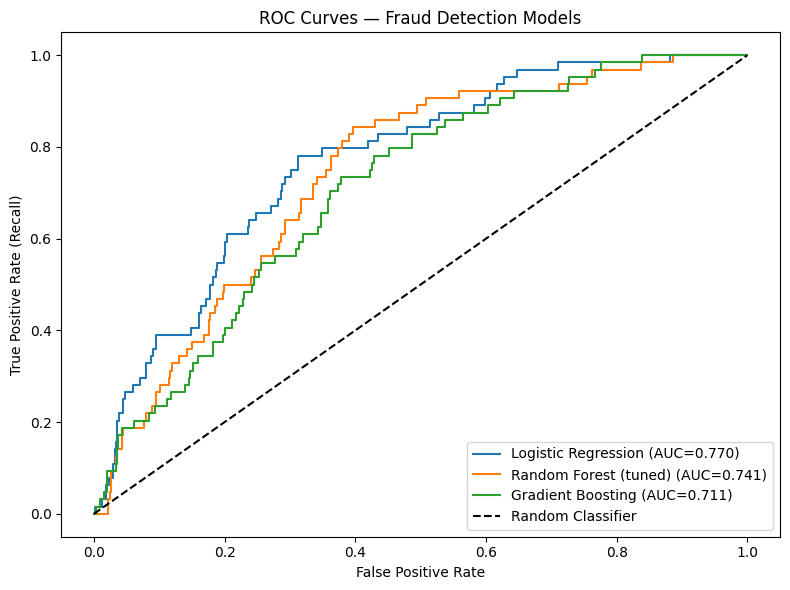

In [24]:
# ROC Curves — all models
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_class_test, y_prob)
    auc = roc_auc_score(y_class_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Fraud Detection Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [25]:
# Classification reports
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'=== {name} ===')
    print(classification_report(y_class_test, y_pred, target_names=['Legitimate', 'Fraud']))
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       0.97      0.73      0.83       936
       Fraud       0.14      0.67      0.24        64

    accuracy                           0.72      1000
   macro avg       0.56      0.70      0.54      1000
weighted avg       0.92      0.72      0.79      1000


=== Random Forest (tuned) ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.90      0.92       936
       Fraud       0.16      0.28      0.20        64

    accuracy                           0.86      1000
   macro avg       0.55      0.59      0.56      1000
weighted avg       0.90      0.86      0.88      1000


=== Gradient Boosting ===
              precision    recall  f1-score   support

  Legitimate       0.94      0.99      0.96       936
       Fraud       0.18      0.05      0.07        64

    accuracy                           0.93      1000
   macro avg       0.56      0.52      0.5

/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


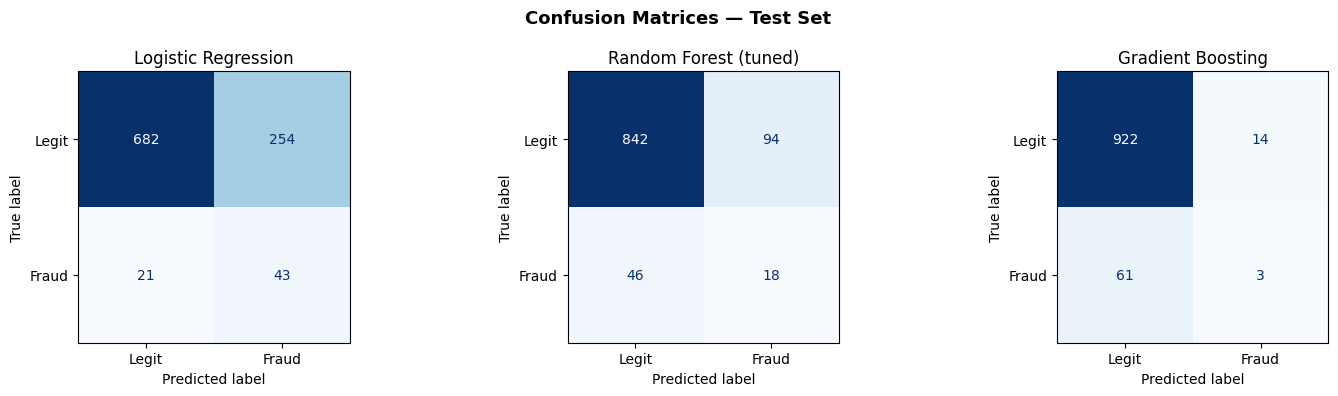

In [26]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_class_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

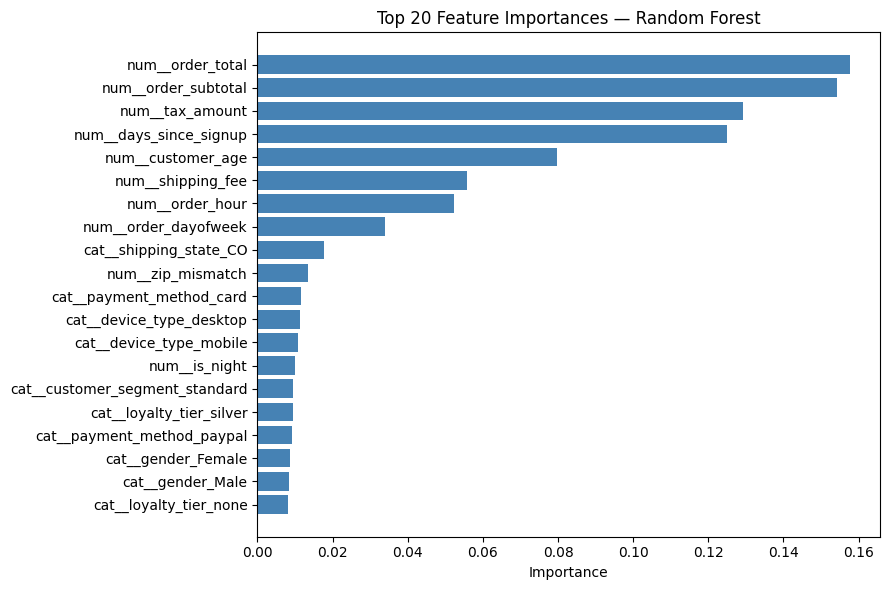

In [27]:
# Feature Importance — best Random Forest model (Ch. 16)
best_rf = grid_rf.best_estimator_
feature_names_out = best_rf.named_steps['preprocess'].get_feature_names_out()
importances = best_rf.named_steps['clf'].feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': feature_names_out,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(9, 6))
plt.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='steelblue')
plt.title('Top 20 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [28]:
# Select best model based on ROC-AUC — evaluated dynamically on the test set
from sklearn.metrics import recall_score, precision_score

print('=== Final Model Selection ===')
model_scores = {}
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc  = roc_auc_score(y_class_test, y_prob)
    rec  = recall_score(y_class_test, y_pred)
    pre  = precision_score(y_class_test, y_pred, zero_division=0)
    model_scores[name] = auc
    print(f'{name:<30} ROC-AUC={auc:.4f}  Recall={rec:.4f}  Precision={pre:.4f}')

best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]
print()
print(f'Selected model: {best_model_name} (ROC-AUC={model_scores[best_model_name]:.4f})')


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


=== Final Model Selection ===
Logistic Regression            ROC-AUC=0.7695  Recall=0.6719  Precision=0.1448
Random Forest (tuned)          ROC-AUC=0.7411  Recall=0.2812  Precision=0.1607
Gradient Boosting              ROC-AUC=0.7110  Recall=0.0469  Precision=0.1765

Selected model: Logistic Regression (ROC-AUC=0.7695)


---
## Section 6 — Deployment

In [29]:
import joblib

# Serialize the best-performing fraud model pipeline
FRAUD_MODEL_PATH = 'fraud_model.pkl'
joblib.dump(best_model, FRAUD_MODEL_PATH)
print(f'Fraud model saved to: {FRAUD_MODEL_PATH}  ({best_model_name})')

# Verify: reload and score
loaded_model = joblib.load(FRAUD_MODEL_PATH)
test_proba = loaded_model.predict_proba(X_test[:5])[:, 1]
print('\nSample fraud probabilities from loaded model:')
for i, p in enumerate(test_proba):
    print(f'  Order {i+1}: {p:.4f} ({"FRAUD" if p > 0.5 else "legit"})')


Fraud model saved to: fraud_model.pkl  (Logistic Regression)

Sample fraud probabilities from loaded model:
  Order 1: 0.2091 (legit)
  Order 2: 0.3629 (legit)
  Order 3: 0.6610 (FRAUD)
  Order 4: 0.1639 (legit)
  Order 5: 0.8088 (FRAUD)


In [30]:
# Scoring Function — how this integrates into the production pipeline (Ch. 17)

def score_new_orders(db_path: str, model_path: str) -> pd.DataFrame:
    """
    Load orders from shop.db, run fraud inference, and return a DataFrame
    sorted by fraud probability. In production this would be called by a
    'Run Scoring' button and write predictions back to the database.
    """
    conn = sqlite3.connect(db_path)
    query = """
        SELECT
            o.order_id, o.order_datetime,
            o.billing_zip, o.shipping_zip, o.shipping_state,
            o.payment_method, o.device_type, o.ip_country,
            o.promo_used, o.order_subtotal, o.shipping_fee,
            o.tax_amount, o.order_total,
            c.gender, c.birthdate, c.created_at,
            c.customer_segment, c.loyalty_tier
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
    """
    raw = pd.read_sql(query, conn)
    conn.close()

    # Apply same feature engineering as training
    raw['order_datetime'] = pd.to_datetime(raw['order_datetime'])
    raw['created_at']     = pd.to_datetime(raw['created_at'])
    raw['birthdate']      = pd.to_datetime(raw['birthdate'])

    raw['zip_mismatch']      = (raw['billing_zip'] != raw['shipping_zip']).astype(int)
    raw['order_hour']        = raw['order_datetime'].dt.hour
    raw['order_dayofweek']   = raw['order_datetime'].dt.dayofweek
    raw['is_weekend']        = (raw['order_dayofweek'] >= 5).astype(int)
    raw['is_night']          = ((raw['order_hour'] >= 22) | (raw['order_hour'] < 6)).astype(int)
    raw['customer_age']      = ((raw['order_datetime'] - raw['birthdate']).dt.days / 365.25).round(1)
    raw['days_since_signup'] = (raw['order_datetime'] - raw['created_at']).dt.days

    X_score = raw[ALL_FEATURES]

    model = joblib.load(model_path)
    raw['fraud_probability'] = model.predict_proba(X_score)[:, 1]
    raw['predicted_fraud']   = (raw['fraud_probability'] > 0.5).astype(int)

    return raw[['order_id', 'order_datetime', 'fraud_probability', 'predicted_fraud']].sort_values(
        'fraud_probability', ascending=False
    )


# Demo
scored = score_new_orders(DB_PATH, FRAUD_MODEL_PATH)
print('Top 10 highest-risk orders:')
scored.head(10)

Top 10 highest-risk orders:


/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/skyler/Library/Python/3.12/lib/python/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,order_id,order_datetime,fraud_probability,predicted_fraud
905,906,2025-09-26 07:24:03,0.9929,1
66,67,2025-07-12 10:44:34,0.9880,1
4464,4465,2025-11-10 10:08:02,0.9825,1
1455,1456,2025-08-03 12:07:30,0.9810,1
382,383,2025-11-27 16:07:54,0.9797,1
210,211,2025-12-23 08:34:23,0.9784,1
2940,2941,2025-12-01 12:26:35,0.9767,1
214,215,2025-09-29 13:46:17,0.9751,1
4218,4219,2025-09-16 17:43:52,0.9745,1
785,786,2025-08-18 12:31:55,0.9741,1


In [31]:
print('=== Pipeline Summary ===')
print(f'Total orders scored:    {len(scored)}')
print(f'Flagged as fraud:       {scored["predicted_fraud"].sum()}')
print(f'Flag rate:              {scored["predicted_fraud"].mean()*100:.2f}%')
print()
print('Deployment artifacts:')
print(f'  Serialized model:  {FRAUD_MODEL_PATH}')
print(f'  Scoring function:  score_new_orders(db_path, model_path)')
print()
print('Integration notes:')
print('  - score_new_orders() is called when the Run Scoring button is clicked in the web app')
print('  - Predictions are sorted by fraud_probability for warehouse review queue')
print('  - Model can be retrained on new labeled data and re-serialized at any time')

=== Pipeline Summary ===
Total orders scored:    5000
Flagged as fraud:       1543
Flag rate:              30.86%

Deployment artifacts:
  Serialized model:  fraud_model.pkl
  Scoring function:  score_new_orders(db_path, model_path)

Integration notes:
  - score_new_orders() is called when the Run Scoring button is clicked in the web app
  - Predictions are sorted by fraud_probability for warehouse review queue
  - Model can be retrained on new labeled data and re-serialized at any time
